## Управление потоком жидкости

Пример графического представления нечеткой системы (FIS)

<img src="assets/fis.png" width="600" style="background-color: white">

Схема алгоритма нечеткого логического вывода

<img src="assets/fis-schema.png" width="600" style="background-color: white">

Имеется наливная емкость (бак) с непрерывным управляемым притоком жидкости (influx) и непрерывным неуправляемым расходом жидкости (flow).

База правил системы нечеткого вывода, соответствующая знаниям эксперта о том, какой необходимо выбрать приток жидкости (influx) чтобы уровень жидкости (level) в баке оставался средним, будет выглядеть следующим образом:
1. ЕСЛИ "уровень жидкости малый" И "расход жидкости большой" ТО "приток жидкости большой";
2. ЕСЛИ "уровень жидкости малый" И "расход жидкости средний" ТО "приток жидкости большой";
3. ЕСЛИ "уровень жидкости малый" И "расход жидкости малый" ТО "приток жидкости средний";
4. ЕСЛИ "уровень жидкости средний" И "расход жидкости большой" ТО "приток жидкости большой";
5. ЕСЛИ "уровень жидкости средний" И "расход жидкости средний" ТО "приток жидкости средний";
6. ЕСЛИ "уровень жидкости средний" И "расход жидкости малый" ТО "приток жидкости средний";
7. ЕСЛИ "уровень жидкости большой" И "расход жидкости большой" ТО "приток жидкости средний";
8. ЕСЛИ "уровень жидкости большой" И "расход жидкости средний" ТО "приток жидкости малый";
9. ЕСЛИ "уровень жидкости большой" И "расход жидкости малый" ТО "приток жидкости малый".

| flow / level | low | middle | high |
| :---: | :---: | :---: | :---: |
| **low** | middle | low | high |
| **middle** | middle | middle | high |
| **high**| high | high | middle |

#### Создание лингвистических переменных

Входные X: level (уровень жидкости) и flow (расход жидкости) \
Выходные Y: influx (приток жидкости)

In [1]:
import numpy as np
from skfuzzy import control as ctrl

level = ctrl.Antecedent(np.arange(1.5, 9.0, 0.1), "level")
flow = ctrl.Antecedent(np.arange(0, 0.6, 0.01), "flow")
influx = ctrl.Consequent(np.arange(0, 0.6, 0.01), "influx")

#### Формирование нечетких переменных для лингвистических переменных и их визуализация

/Users/user/Projects/python/mai-examples/lec3.2/.venv/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


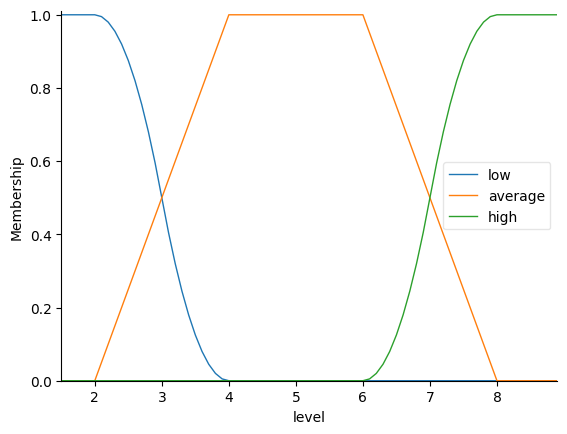

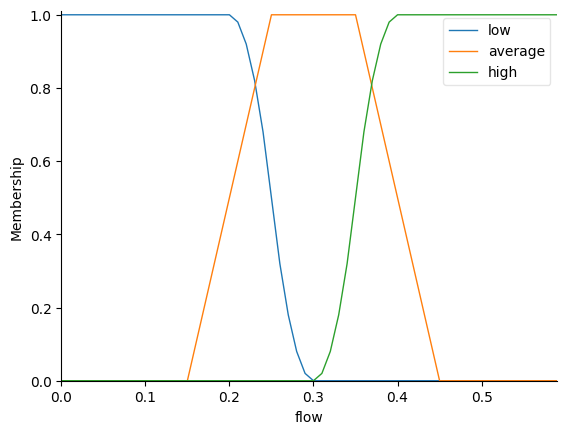

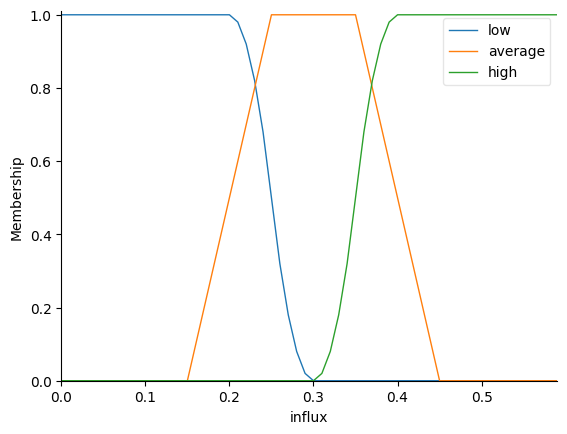

In [2]:
import skfuzzy as fuzz

level["low"] = fuzz.zmf(level.universe, 2, 4)
level["average"] = fuzz.trapmf(level.universe, [2, 4, 6, 8])
level["high"] = fuzz.smf(level.universe, 6, 8)
level.view()

flow["low"] = fuzz.zmf(flow.universe, 0.2, 0.3)
flow["average"] = fuzz.trapmf(flow.universe, [0.15, 0.25, 0.35, 0.45])
flow["high"] = fuzz.smf(flow.universe, 0.3, 0.4)
flow.view()

influx["low"] = fuzz.zmf(influx.universe, 0.2, 0.3)
influx["average"] = fuzz.trapmf(influx.universe, [0.15, 0.25, 0.35, 0.45])
influx["high"] = fuzz.smf(influx.universe, 0.3, 0.4)
influx.view()

#### Формирование и визуализация базы нечетких правил

В случае ошибки необходимо в файле
```
.venv/lib/python3.13/site-packages/skfuzzy/control/visualization.py
```
удалить лишний отступ на 182 строке, должно быть:
```python
        if not matplotlib_present:
            raise ImportError("`ControlSystemVisualizer` can only be used "
                              "with `matplotlib` present in the system.")

        self.ctrl = control_system

        self.fig, self.ax = plt.subplots()
```

(<Figure size 640x480 with 1 Axes>, <Axes: >)

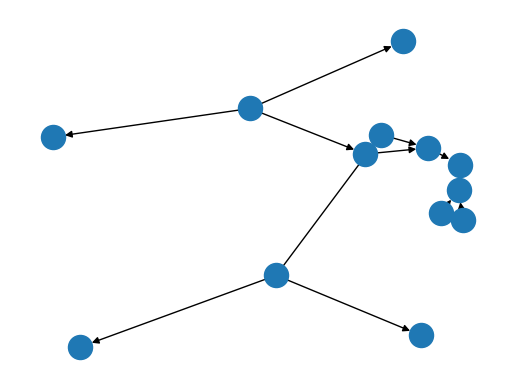

In [3]:
rule1 = ctrl.Rule(level["low"] & flow["high"], influx["high"])
rule2 = ctrl.Rule(level["low"] & flow["average"], influx["high"])
rule3 = ctrl.Rule(level["low"] & flow["low"], influx["average"])
rule4 = ctrl.Rule(level["average"] & flow["high"], influx["high"])
rule5 = ctrl.Rule(level["average"] & flow["average"], influx["average"])
rule6 = ctrl.Rule(level["average"] & flow["low"], influx["average"])
rule7 = ctrl.Rule(level["high"] & flow["high"], influx["average"])
rule8 = ctrl.Rule(level["high"] & flow["average"], influx["low"])
rule9 = ctrl.Rule(level["high"] & flow["low"], influx["low"])

rule1.view()

#### Создание нечеткой системы и добавление нечетких правил в базу знаний нечеткой системы

In [4]:
influx_ctrl = ctrl.ControlSystem(
    [
        rule1,
        rule2,
        rule3,
        rule4,
        rule5,
        rule6,
        rule7,
        rule8,
        rule9,
    ]
)

influxes = ctrl.ControlSystemSimulation(influx_ctrl)

#### Пример расчета выходной переменной influx на основе входных переменных level и flow

Система также формирует подробный журнал выполнения процесса нечеткого логического вывода

In [5]:
influxes.input["level"] = 2.5
influxes.input["flow"] = 0.4
influxes.compute()
influxes.print_state()
influxes.output["influx"]

 Antecedents 
Antecedent: level                   = 2.5
  - low                             : 0.875
  - average                         : 0.25
  - high                            : 0.0
Antecedent: flow                    = 0.4
  - low                             : 0.0
  - average                         : 0.4999999999999997
  - high                            : 1.0

 Rules 
RULE #0:
  IF level[low] AND flow[high] THEN influx[high]
	AND aggregation function : fmin
	OR aggregation function  : fmax

  Aggregation (IF-clause):
  - level[low]                                             : 0.875
  - flow[high]                                             : 1.0
                                 level[low] AND flow[high] = 0.875
  Activation (THEN-clause):
                                              influx[high] : 0.875

RULE #1:
  IF level[low] AND flow[average] THEN influx[high]
	AND aggregation function : fmin
	OR aggregation function  : fmax

  Aggregation (IF-clause):
  - level[low]       

np.float64(0.4315251220586045)

#### Визуализация функции принадлежности для выходной переменной influx

Функция получена в процессе аккумуляции и используется для дефаззификации значения выходной переменной influx

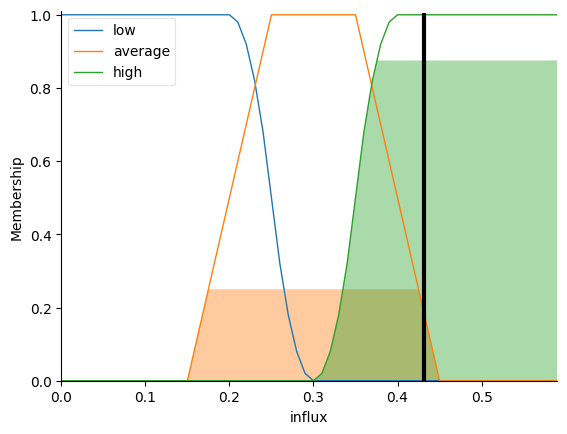

In [6]:
influx.view(sim=influxes)

#### Отображение пространства управления

С помощью библиотеки matplotlib и симуляций можно визуализировать поверхность системы управления в трех измерениях.

Визуализация поверхности управления нужна для:
1. Поиска "артефактов". На графике сразу видно, есть ли у системы резкие скачки, разрывы или "мертвые зоны", где управление ведет себя нестабильно. В идеале поверхность должна быть плавной.
2. Проверки логики. Можно наглядно увидеть, как система реагирует на крайние значения. Например, если уровень (x) максимален, а поток (y) минимален — адекватен ли выходной сигнал (z)?
3. Демонстрации. Это самый быстрый способ доказать, что  модель работает во всем диапазоне входных данных, а не только в паре тестовых точек.

Полученная визуализация строит "карту решений" нечеткой системы. Если на ней видны странные пики или провалы — значит, в правилах есть ошибка.

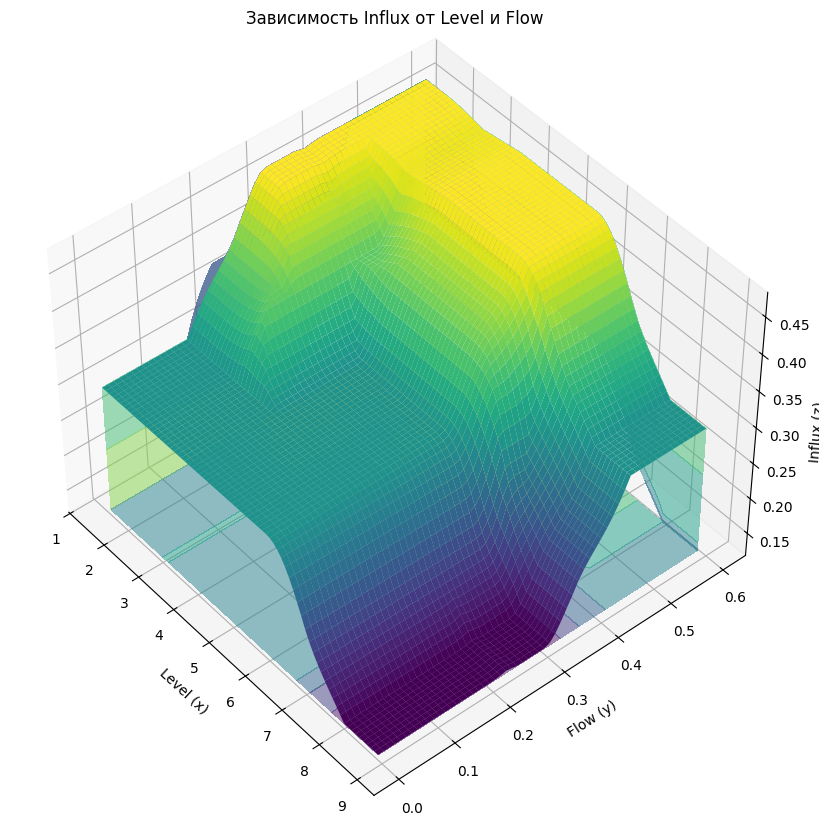

In [7]:
import matplotlib.pyplot as plt

x = np.arange(1.5, 9.0, 0.1)
y = np.arange(0, 0.6, 0.01)
z = np.zeros((len(x), len(y)))

for i in range(len(x)):
    for j in range(len(y)):
        influxes.input["level"] = x[i]
        influxes.input["flow"] = y[j]
        influxes.compute()
        z[i, j] = influxes.output["influx"]

# Создаем сетку координат на основе x и y
# indexing='ij' критически важен, так как z имеет размер (len(x), len(y))
X, Y = np.meshgrid(x, y, indexing="ij")

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(1, 1, 1, projection="3d")

ax.set_title("Зависимость Influx от Level и Flow")
ax.set_xlabel("Level (x)")
ax.set_ylabel("Flow (y)")
ax.set_zlabel("Influx (z)")

# Передаем X и Y (матрицы), а не x и y (векторы)
surf = ax.plot_surface(
    X, Y, z, rstride=1, cstride=1, cmap="viridis", linewidth=0.4, antialiased=True
)
cset = ax.contourf(X, Y, z, zdir="z", offset=z.min(), cmap="viridis", alpha=0.5)
cset = ax.contourf(X, Y, z, zdir="x", offset=x.min(), cmap="viridis", alpha=0.5)
cset = ax.contourf(X, Y, z, zdir="y", offset=y.max(), cmap="viridis", alpha=0.5)

ax.view_init(45, -40)

1. ЕСЛИ "уровень жидкости малый" И "расход жидкости большой" ТО "приток жидкости большой";
2. ЕСЛИ "уровень жидкости малый" И "расход жидкости средний" ТО "приток жидкости большой";
3. ЕСЛИ "уровень жидкости малый" И "расход жидкости малый" ТО "приток жидкости средний";
4. ЕСЛИ "уровень жидкости средний" И "расход жидкости большой" ТО "приток жидкости большой";
5. ЕСЛИ "уровень жидкости средний" И "расход жидкости средний" ТО "приток жидкости средний";
6. ЕСЛИ "уровень жидкости средний" И "расход жидкости малый" ТО "приток жидкости средний";
7. ЕСЛИ "уровень жидкости большой" И "расход жидкости большой" ТО "приток жидкости средний";
8. ЕСЛИ "уровень жидкости большой" И "расход жидкости средний" ТО "приток жидкости малый";
9. ЕСЛИ "уровень жидкости большой" И "расход жидкости малый" ТО "приток жидкости малый".